In [1]:
# V2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def euler_maruyama(x0, z, t_start = 0, t_end = 1,  a = lambda x, t: 0, b = lambda x, t: 1):
  """
  Numerical solution of a Stochastic Differential Equation using Euler-Maruyama method.

  Args:
    x0 (float): The initial value of the process.
    z (np.ndarray): Array of simulated standard normal random variates to generate the increments.
    t_start (float): Start time of the simulation (default 0).
    t_end (float): End time of the simulation (default 1).
    a (function): The drift function a(x, t) (default is lambda x, t: 0).
    b (function): The diffusion function b(x, t) (default is lambda x, t: 1).

  Returns:
    np.ndarray: Simulated trajectory of the process.
  """
  n = z.size
  h = (t_end-t_start)/n
  sqrth = np.sqrt(h)
  t = np.linspace(t_start, t_end, n+1)

  X = np.zeros(n+1)
  X[0] = x0

  for i in range(1, n+1):
    X[i] = X[i-1] + a(X[i-1], t[i-1]) * h + z[i-1] * b(X[i-1], t[i-1]) * sqrth

  return X

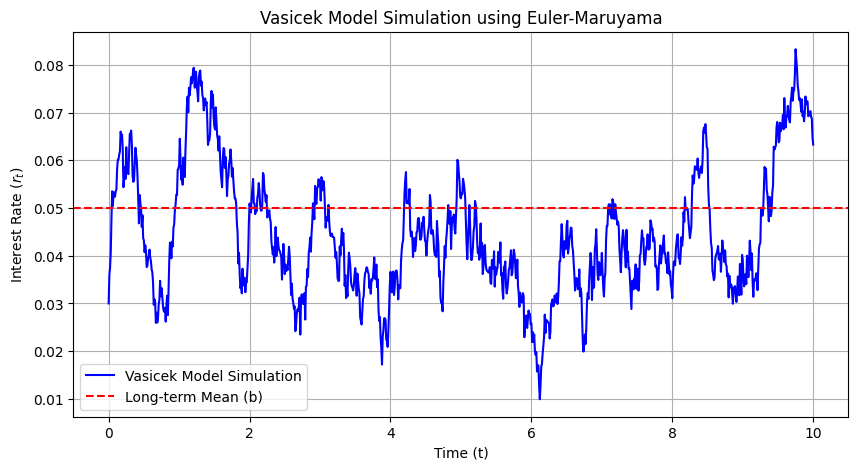

In [4]:
# Vasicek model parameters
a = 3.0       # Speed of mean reversion
b = 0.05      # Long-term mean interest rate
sigma = 0.03  # Volatility
x0 = 0.03     # Initial interest rate
T = 10.0      # Time horizon in years
n = 1000      # Number of steps

# Generate standard normal random variables
np.random.seed(0)
z = np.random.normal(0, 1, n)

# Define drift a_func(x) and diffusion b_func(x) for Vasicek: dx = a*(b - x)*dt + sigma*dWt
a_func = lambda x, t: a * (b - x)
b_func = lambda x, t: sigma

# Run the simulation
t_axis = np.linspace(0, T, n + 1)
rates = euler_maruyama(x0, z, 0, T, a=a_func, b=b_func)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_axis, rates, label='Vasicek Model Simulation', color='blue')
plt.axhline(y=b, color='red', linestyle='--', label='Long-term Mean (b)')
plt.title('Vasicek Model Simulation using Euler-Maruyama')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate ($r_t$)')
plt.legend()
plt.grid(True)
plt.show()

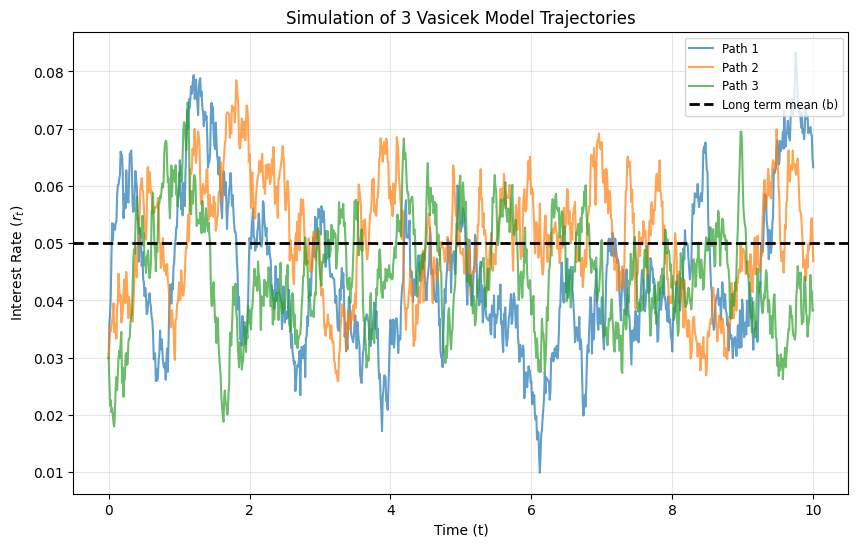

In [5]:
T = 10
num_paths = 3
plt.figure(figsize=(10, 6))

np.random.seed(0)
for i in range(num_paths):
    z_path = np.random.normal(0, 1, n)
    rates_path = euler_maruyama(x0, z_path, 0, T, a=a_func, b=b_func)
    plt.plot(t_axis, rates_path, alpha=0.7, label=f'Path {i+1}' if i < 5 else "")

plt.axhline(y=b, color='black', linestyle='--', linewidth=2, label='Long term mean (b)')
plt.title(f'Simulation of {num_paths} Vasicek Model Trajectories')
plt.xlabel(r'Time (t)')
plt.ylabel(r'Interest Rate ($r_t$)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.3)
plt.show()

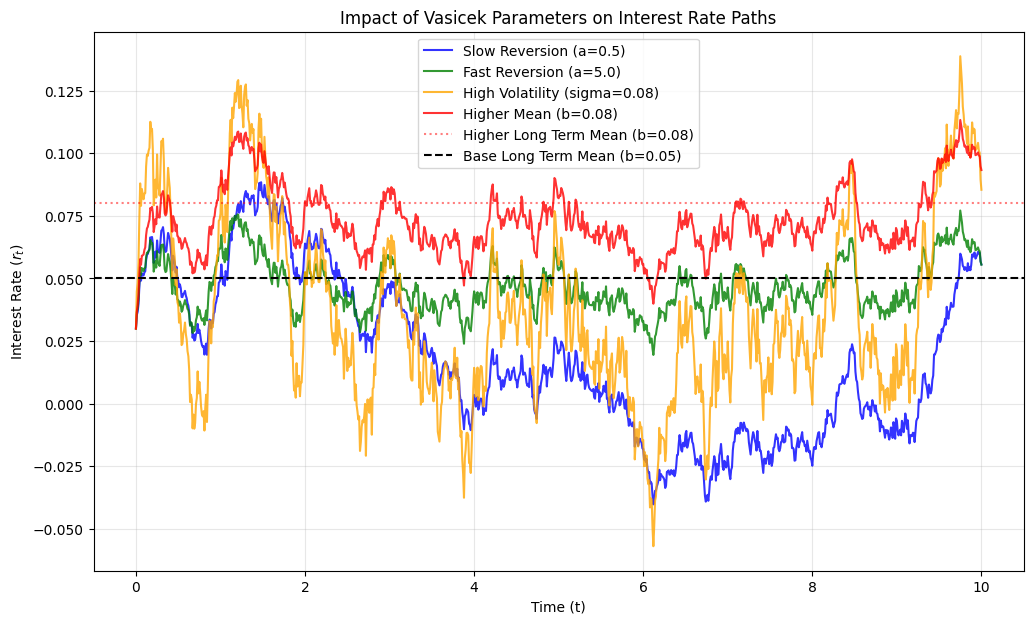

In [6]:
# Base parameters
x0 = 0.03
T = 10.0
n = 1000
t_axis = np.linspace(0, T, n + 1)
np.random.seed(0)
z = np.random.normal(0, 1, n)

# Scenarios to compare
scenarios = [
    {'a': 0.5, 'b': 0.05, 'sigma': 0.03, 'label': 'Slow Reversion (a=0.5)', 'color': 'blue'},
    {'a': 5.0, 'b': 0.05, 'sigma': 0.03, 'label': 'Fast Reversion (a=5.0)', 'color': 'green'},
    {'a': 3.0, 'b': 0.05, 'sigma': 0.08, 'label': 'High Volatility (sigma=0.08)', 'color': 'orange'},
    {'a': 3.0, 'b': 0.08, 'sigma': 0.03, 'label': 'Higher Mean (b=0.08)', 'color': 'red'},
]

plt.figure(figsize=(12, 7))

for s in scenarios:
    a_func = lambda x, t, s=s: s['a'] * (s['b'] - x)
    b_func = lambda x, t, s=s: s['sigma']

    path = euler_maruyama(x0, z, 0, T, a=a_func, b=b_func)
    plt.plot(t_axis, path, label=s['label'], color=s['color'], alpha=0.8)
    if s['label'] == 'Higher Mean (b=0.08)':
        plt.axhline(y=s['b'], color=s['color'], linestyle=':', alpha=0.5, label='Higher Long Term Mean (b=0.08)')

plt.axhline(y=0.05, color='black', linestyle='--', label='Base Long Term Mean (b=0.05)')
plt.title('Impact of Vasicek Parameters on Interest Rate Paths')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate ($r_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Model with jumps

In [7]:
def jump_model(x0, jump_intensity, zstart=None, t_start = 0, t_end = 1,  a = lambda x, t: 0, b = lambda x, t: 1):
  n_jumps = np.random.poisson(jump_intensity*(t_end-t_start))
  jump_times = np.insert(np.sort(np.random.uniform(t_start, t_end, n_jumps)), 0, 0)

  if zstart is None:
    z = np.random.normal(0, 1, n_jumps)
  else:
    # We use the provided values for z as the first of our random variates (we generate the rest)
    if zstart.size >= n_jumps:
      z = zstart[:n_jumps]
    else:
      z = np.concatenate((zstart, np.random.normal(0, 1, n_jumps-zstart.size)))

  X = np.zeros(n_jumps+1)
  X[0] = x0

  average_distance = 1/jump_intensity
  sqrtavg = np.sqrt(average_distance)

  for i in range(1, n_jumps+1):
    X[i] = X[i-1] + a(X[i-1], jump_times[i]) * average_distance + z[i-1] * b(X[i-1], jump_times[i]) * sqrtavg

  return jump_times, X


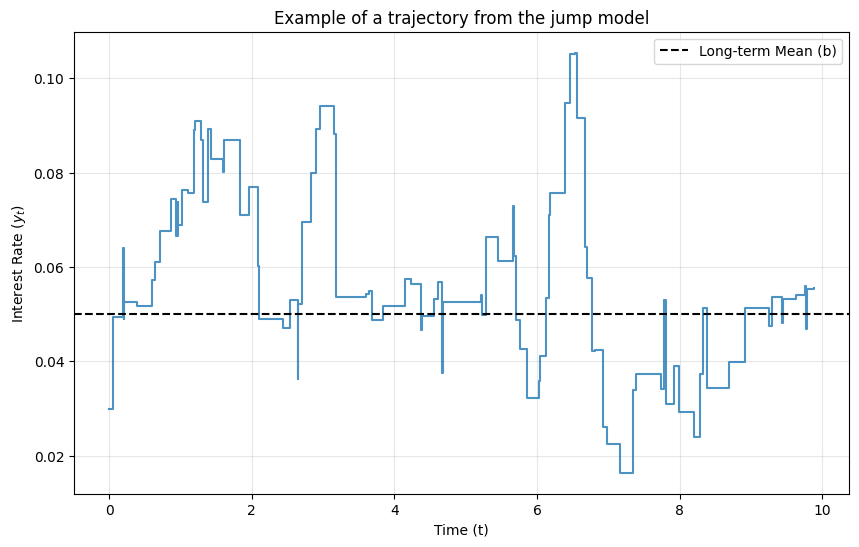

In [8]:
# Model parameters
a = 1.0       # Speed of mean reversion
b = 0.05      # Long-term mean interest rate
sigma = 0.03  # Volatility
x0 = 0.03     # Initial interest rate
T = 10.0      # Time horizon in years
jump_intensity = 10.0

# Define drift a_func(x) and diffusion b_func(x)
a_func = lambda x, t: a * (b - x)
b_func = lambda x, t: sigma

# Generate and plot 3 paths
plt.figure(figsize=(10, 6))
np.random.seed(0)

times, path = jump_model(x0, jump_intensity, t_start=0, t_end=T, a=a_func, b=b_func)
plt.step(times, path, where='post', alpha=0.8)

plt.axhline(y=b, color='black', linestyle='--', label='Long-term Mean (b)')
plt.title(f'Example of a trajectory from the jump model')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate ($y_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

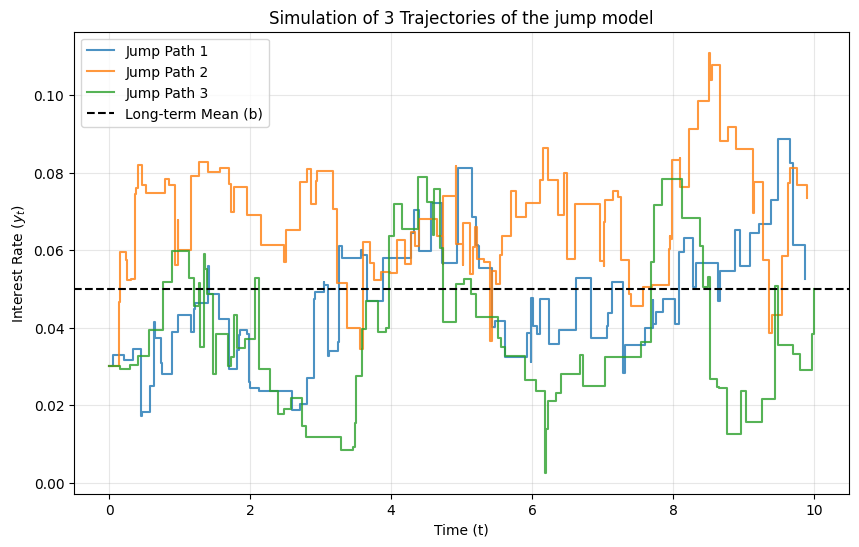

In [9]:
# Model parameters
a = 1.0       # Speed of mean reversion
b = 0.05      # Long-term mean interest rate
sigma = 0.03  # Volatility
x0 = 0.03     # Initial interest rate
T = 10.0      # Time horizon in years
jump_intensity = 10.0

# Define drift a_func(x) and diffusion b_func(x)
a_func = lambda x, t: a * (b - x)
b_func = lambda x, t: sigma

# Generate and plot 3 paths
plt.figure(figsize=(10, 6))
np.random.seed(42)

for i in range(3):
    times, path = jump_model(x0, jump_intensity, t_start=0, t_end=T, a=a_func, b=b_func)
    plt.step(times, path, where='post', label=f'Jump Path {i+1}', alpha=0.8)

plt.axhline(y=b, color='black', linestyle='--', label='Long-term Mean (b)')
plt.title(f'Simulation of 3 Trajectories of the jump model')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate ($y_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

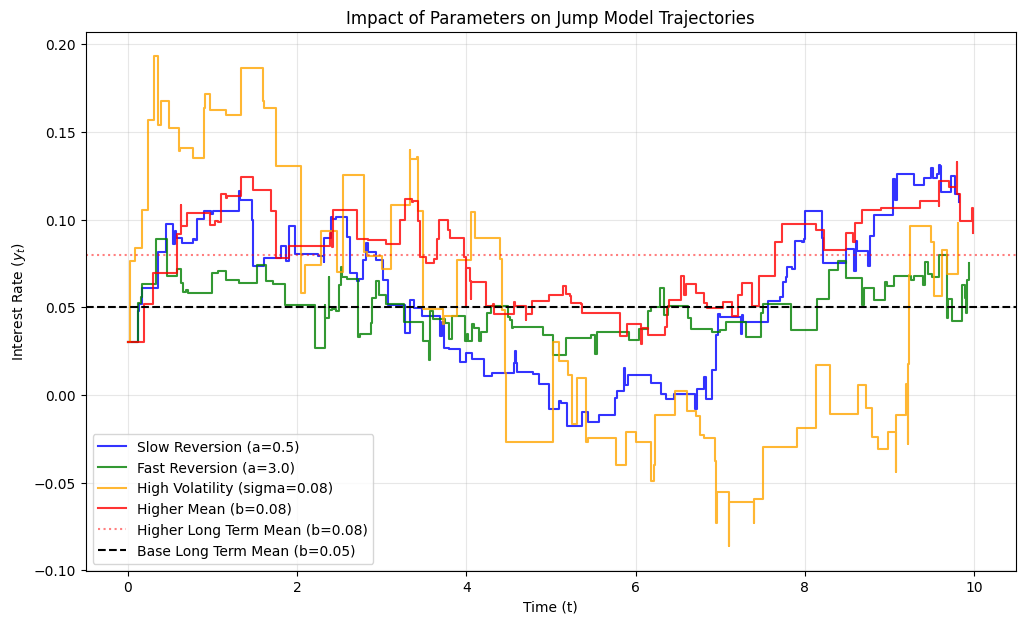

In [10]:
# Base parameters for comparison
x0 = 0.03
T = 10.0
jump_intensity = 10.0

# Scenarios to compare for the jump model
scenarios = [
    {'a': 0.5, 'b': 0.05, 'sigma': 0.03, 'label': 'Slow Reversion (a=0.5)', 'color': 'blue'},
    {'a': 3.0, 'b': 0.05, 'sigma': 0.03, 'label': 'Fast Reversion (a=3.0)', 'color': 'green'},
    {'a': 1.0, 'b': 0.05, 'sigma': 0.08, 'label': 'High Volatility (sigma=0.08)', 'color': 'orange'},
    {'a': 1.0, 'b': 0.08, 'sigma': 0.03, 'label': 'Higher Mean (b=0.08)', 'color': 'red'},
]

plt.figure(figsize=(12, 7))
np.random.seed(0)

z = np.random.normal(0, 1, int(2*jump_intensity*T))

for s in scenarios:
    a_func = lambda x, t: s['a'] * (s['b'] - x)
    b_func = lambda x, t: s['sigma']

    # We simulate paths using the same seed/logic where possible for comparison
    times, path = jump_model(x0, jump_intensity, zstart=z, t_start=0, t_end=T, a=a_func, b=b_func)
    plt.step(times, path, where='post', label=s['label'], color=s['color'], alpha=0.8)

    if s['label'] == 'Higher Mean (b=0.08)':
        plt.axhline(y=s['b'], color=s['color'], linestyle=':', alpha=0.5, label='Higher Long Term Mean (b=0.08)')

plt.axhline(y=0.05, color='black', linestyle='--', label='Base Long Term Mean (b=0.05)')
plt.title('Impact of Parameters on Jump Model Trajectories')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate ($y_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
def resample(z, P, p, T):
  return np.sum(np.reshape(z, (T*2**(p), 2**(P-p))), axis=1)/np.sqrt(2**(P-p))

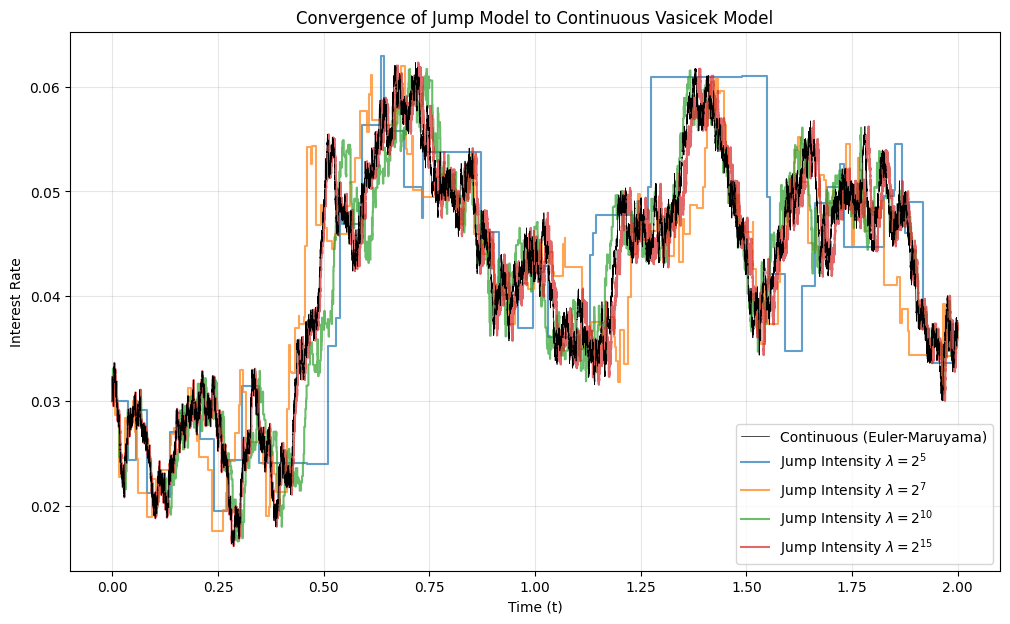

In [12]:
# Visual representation of convergence theorem

# Parameters
x0 = 0.03
a, b, sigma = 3.0, 0.05, 0.03
T = 2

a_func = lambda x, t: a * (b - x)
b_func = lambda x, t: sigma

np.random.seed(0)
psims = [5, 7, 10, 15]
P = np.max(psims)
N = T*2**P
t = np.linspace(0, T, N+1)
z = np.random.normal(size=N)

# 1. Continuous Simulation (Euler-Maruyama)
path_cont = euler_maruyama(x0, z, 0, T, a=a_func, b=b_func)

# 2. Jump Simulations with different intensities
plt.figure(figsize=(12, 7))

# Plot Continuous reference
plt.plot(t, path_cont, label='Continuous (Euler-Maruyama)', color='black', linewidth=.5, zorder=5)

# Plot Jump models
for p in psims:
    z_p = resample(z, P, p, T)
    t_p, path_p = jump_model(x0, 2**p, zstart=z_p, t_start=0, t_end=T, a=a_func, b=b_func)
    plt.step(t_p, path_p, where='post', label=fr'Jump Intensity $\lambda=2^{{{p}}}$', alpha=0.7)

plt.title('Convergence of Jump Model to Continuous Vasicek Model')
plt.xlabel('Time (t)')
plt.ylabel('Interest Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Monte Carlo Pricing


In [13]:
def monte_carlo_vasicek_pricing(x0, T, num_simulations, num_steps, payoff_function, a, b, sigma):
    discounted_payoffs = []
    t_axis = np.linspace(0, T, num_steps + 1)

    a_func = lambda x, t: a * (b - x)
    b_func = lambda x, t: sigma

    for _ in range(num_simulations):
        # Generate standard normal random variates for this path
        z = np.random.normal(0, 1, num_steps)

        # Simulate the interest rate path
        path = euler_maruyama(x0, z, 0, T, a=a_func, b=b_func)

        # Calculate the integral of the rates for discounting using trapezoidal rule
        integral_rate = np.trapezoid(path, t_axis)
        discount_factor = np.exp(-integral_rate)

        # Apply the payoff function to the entire path
        payoff = payoff_function(path)

        # Calculate discounted payoff and add to list
        discounted_payoffs.append(payoff * discount_factor)

    # Return the average of all discounted payoffs
    return np.mean(discounted_payoffs)

In [14]:
def bond_payoff(path):
    """
    This is the simplest payoff function, a bond paying 1 at maturity.

    Args:
        path (np.ndarray): The simulated interest rate path (the argument is irrelevant to the output but it is necesary because of the general syntax of the payoff call).

    Returns:
        float: The payoff of the caplet.
    """
    return 1

In [15]:
def caplet_payoff(strike, path):
    """
    Calculates the payoff for a caplet the terminal interest rate.

    Args:
        strike (float): The strike price of the option.
        path (np.ndarray): The simulated interest rate path.

    Returns:
        float: The payoff of the caplet.
    """
    return max(0, path[-1] - strike)

In [16]:
def asian_call_payoff(strike, path):
    """
    Calculates the payoff for a European Asian call option.

    Args:
        strike (float): The strike price of the option.
        path (np.ndarray): The simulated interest rate path.

    Returns:
        float: The payoff of the Asian call option.
    """
    average_rate = np.mean(path)
    return max(0, average_rate - strike)

In [17]:
baseline_vasicek_params = {'a': 0.3, 'b': 0.05, 'sigma': 0.03, 'x0': 0.03, 'T': 1.0}
baseline_mc_params = {'num_simulations': 5000, 'num_steps': 250}

caplet_strike = 0.04
asian_call_strike = 0.04

# print("Baseline Vasicek Parameters:", baseline_vasicek_params)
# print("Baseline Monte Carlo Parameters:", baseline_mc_params)
# print("Caplet Strike Price:", caplet_strike)
# print("Asian Call Strike Price:", asian_call_strike)

In [ ]:
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']

T = baseline_mc_params['T']
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Calculate baseline bond price
baseline_bond_price = monte_carlo_vasicek_pricing(
    x0, T, num_simulations, num_steps, bond_payoff, a, b, sigma
)

# Calculate baseline caplet price
baseline_caplet_price = monte_carlo_vasicek_pricing(
    x0, T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), a, b, sigma
)

# Calculate baseline Asian call option price
baseline_asian_call_price = monte_carlo_vasicek_pricing(
    x0, T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), a, b, sigma
)

print(f"Baseline Bond Price: {baseline_bond_price:.6f}")
print(f"Baseline Caplet Price (Strike={caplet_strike}): {baseline_caplet_price:.6f}")
print(f"Baseline Asian Call Price (Strike={asian_call_strike}): {baseline_asian_call_price:.6f}")

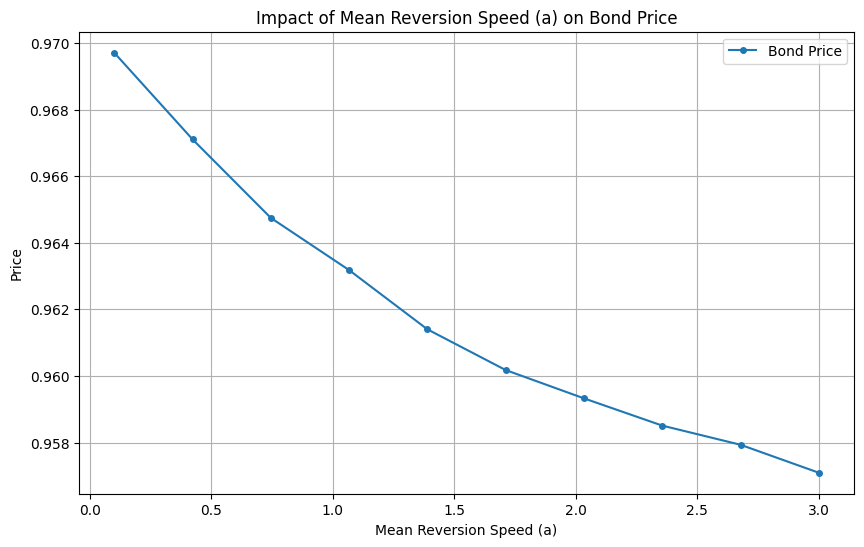

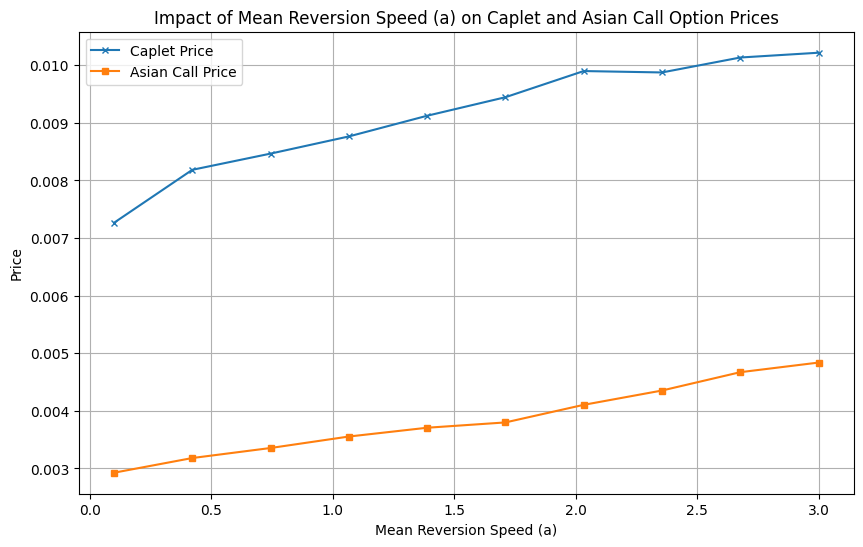

In [18]:
# Impact of a

a_values = np.linspace(0.1, 3.0, 10)

bond_prices_a = []
caplet_prices_a = []
asian_call_prices_a = []

# Extract baseline MC parameters
T = baseline_vasicek_params['T']
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Keep other Vasicek parameters at baseline
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']

for current_a in a_values:
    # Calculate bond price
    bond_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, bond_payoff, current_a, b, sigma
    )
    bond_prices_a.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), current_a, b, sigma
    )
    caplet_prices_a.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), current_a, b, sigma
    )
    asian_call_prices_a.append(asian_call_price)


# Plot bond prices
plt.figure(figsize=(10, 6))
plt.plot(a_values, bond_prices_a, label='Bond Price', marker='o', markersize=4)
plt.title('Impact of Mean Reversion Speed (a) on Bond Price')
plt.xlabel('Mean Reversion Speed (a)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot caplet and Asian call option prices
plt.figure(figsize=(10, 6))
plt.plot(a_values, caplet_prices_a, label='Caplet Price', marker='x', markersize=4)
plt.plot(a_values, asian_call_prices_a, label='Asian Call Price', marker='s', markersize=4)
plt.title('Impact of Mean Reversion Speed (a) on Caplet and Asian Call Option Prices')
plt.xlabel('Mean Reversion Speed (a)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

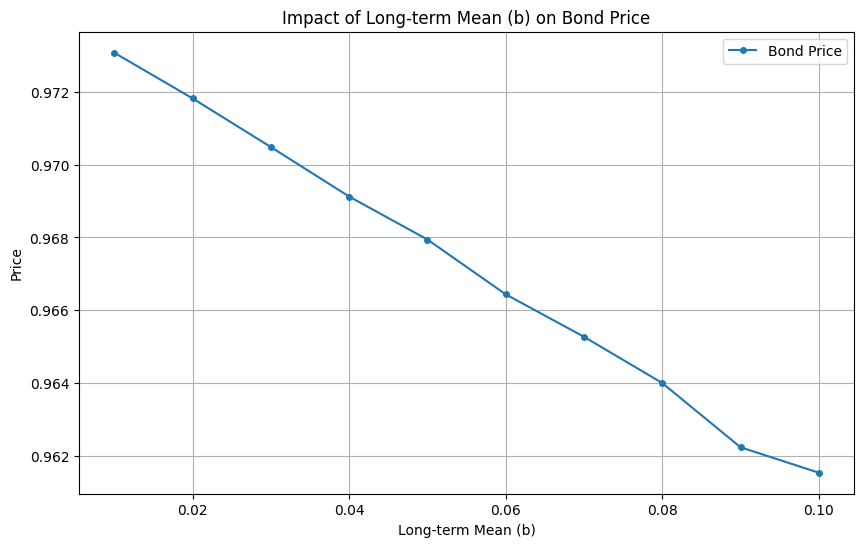

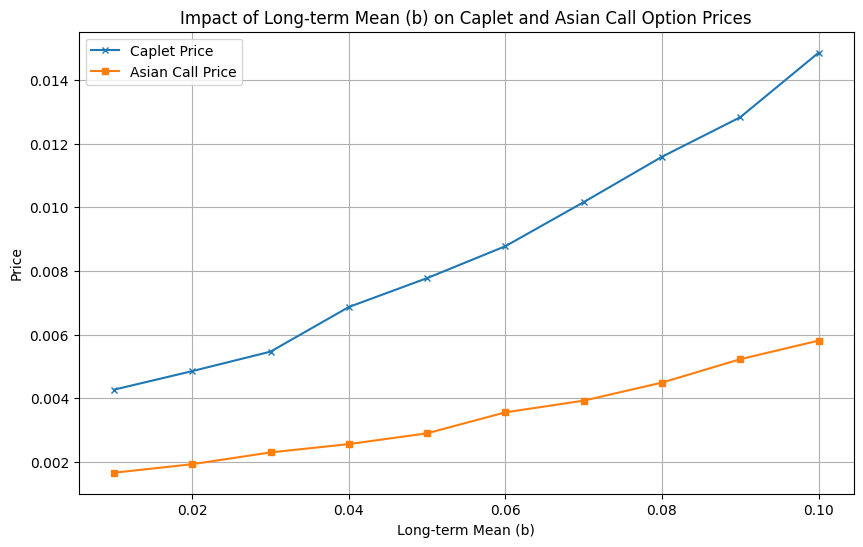

In [19]:
# Impact of b

b_values = np.linspace(0.01, 0.10, 10)

bond_prices_b = []
caplet_prices_b = []
asian_call_prices_b = []

# Extract baseline MC parameters
T = baseline_vasicek_params['T']
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Keep other Vasicek parameters at baseline
a = baseline_vasicek_params['a']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']

for current_b in b_values:
    # Calculate bond price
    bond_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, bond_payoff, a, current_b, sigma
    )
    bond_prices_b.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), a, current_b, sigma
    )
    caplet_prices_b.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), a, current_b, sigma
    )
    asian_call_prices_b.append(asian_call_price)

# Plot bond prices
plt.figure(figsize=(10, 6))
plt.plot(b_values, bond_prices_b, label='Bond Price', marker='o', markersize=4)
plt.title('Impact of Long-term Mean (b) on Bond Price')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot caplet and Asian call option prices
plt.figure(figsize=(10, 6))
plt.plot(b_values, caplet_prices_b, label='Caplet Price', marker='x', markersize=4)
plt.plot(b_values, asian_call_prices_b, label='Asian Call Price', marker='s', markersize=4)
plt.title('Impact of Long-term Mean (b) on Caplet and Asian Call Option Prices')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

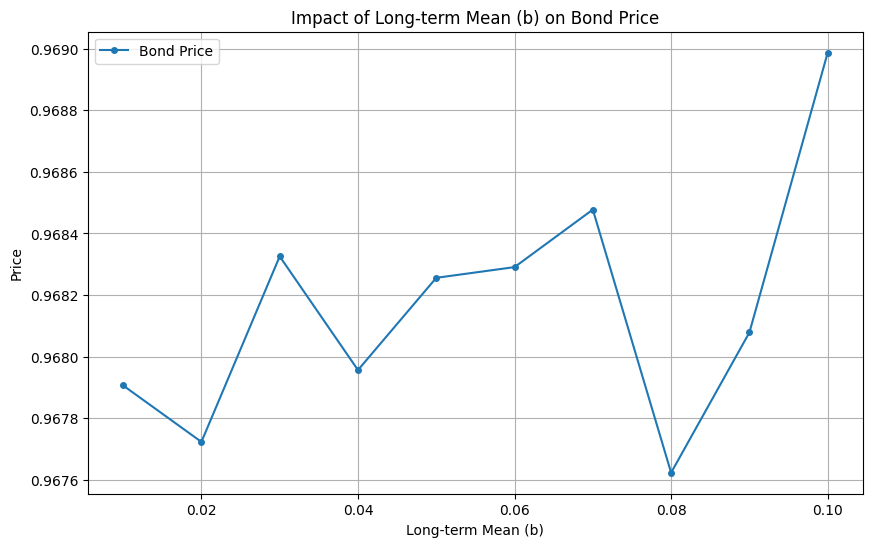

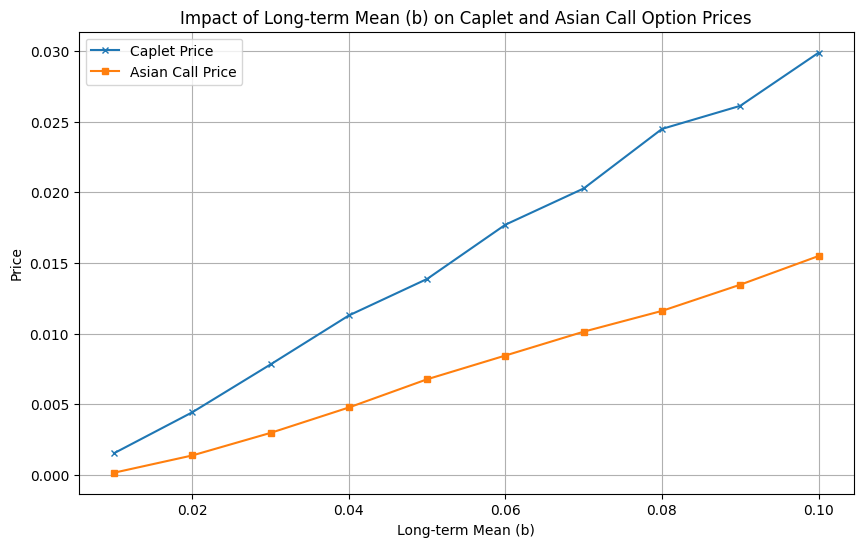

In [20]:
#Impact of sigma

sigma_values = np.linspace(0.01, 0.10, 10)

bond_prices_sigma = []
caplet_prices_sigma = []
asian_call_prices_sigma = []

# Extract baseline MC parameters
T = baseline_vasicek_params['T']
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Keep other Vasicek parameters at baseline
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
x0 = baseline_vasicek_params['x0']

for current_sigma in sigma_values:
    # Calculate bond price
    bond_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, bond_payoff, a, b, current_sigma
    )
    bond_prices_sigma.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), a, b, current_sigma
    )
    caplet_prices_sigma.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_vasicek_pricing(
        x0, T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), a, b, current_sigma
    )
    asian_call_prices_sigma.append(asian_call_price)

# Plot bond prices
plt.figure(figsize=(10, 6))
plt.plot(sigma_values, bond_prices_sigma, label='Bond Price', marker='o', markersize=4)
plt.title('Impact of Long-term Mean (b) on Bond Price')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot caplet and Asian call option prices
plt.figure(figsize=(10, 6))
plt.plot(sigma_values, caplet_prices_sigma, label='Caplet Price', marker='x', markersize=4)
plt.plot(sigma_values, asian_call_prices_sigma, label='Asian Call Price', marker='s', markersize=4)
plt.title('Impact of Long-term Mean (b) on Caplet and Asian Call Option Prices')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

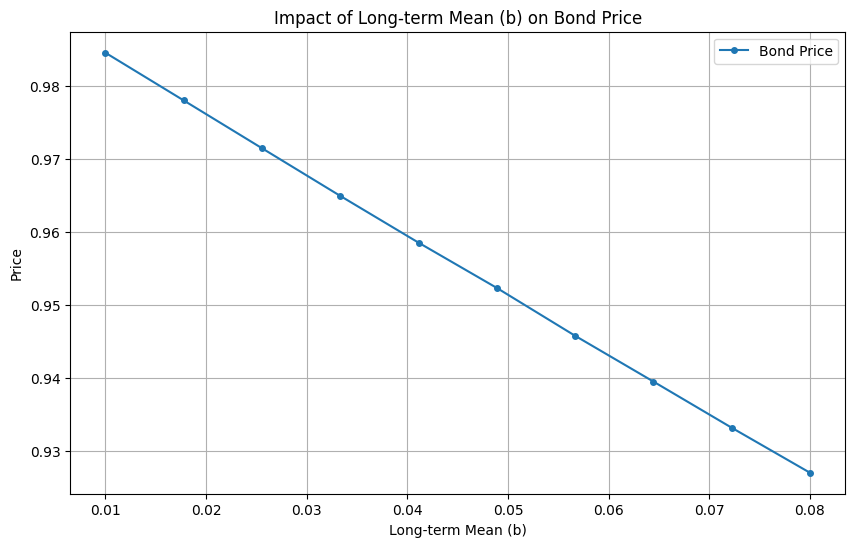

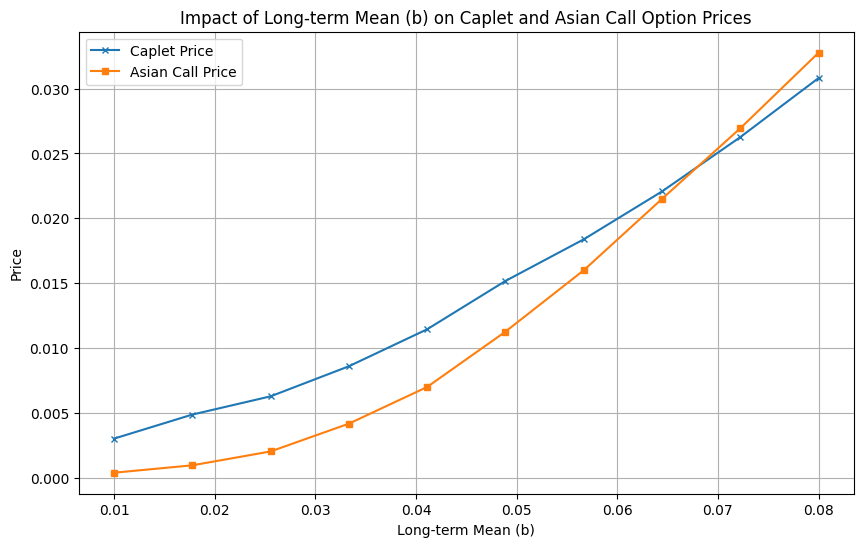

In [21]:
#impact of x0

x0_values = np.linspace(0.01, 0.08, 10)

bond_prices_x0 = []
caplet_prices_x0 = []
asian_call_prices_x0 = []

# Extract baseline MC parameters
T = baseline_vasicek_params['T']
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Keep other Vasicek parameters at baseline
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']

for current_x0 in x0_values:
    # Calculate bond price
    bond_price = monte_carlo_vasicek_pricing(
        current_x0, T, num_simulations, num_steps, bond_payoff, a, b, sigma
    )
    bond_prices_x0.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_vasicek_pricing(
        current_x0, T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), a, b, sigma
    )
    caplet_prices_x0.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_vasicek_pricing(
        current_x0, T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), a, b, sigma
    )
    asian_call_prices_x0.append(asian_call_price)

# Plot bond prices
plt.figure(figsize=(10, 6))
plt.plot(x0_values, bond_prices_x0, label='Bond Price', marker='o', markersize=4)
plt.title('Impact of Long-term Mean (b) on Bond Price')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot caplet and Asian call option prices
plt.figure(figsize=(10, 6))
plt.plot(x0_values, caplet_prices_x0, label='Caplet Price', marker='x', markersize=4)
plt.plot(x0_values, asian_call_prices_x0, label='Asian Call Price', marker='s', markersize=4)
plt.title('Impact of Long-term Mean (b) on Caplet and Asian Call Option Prices')
plt.xlabel('Long-term Mean (b)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

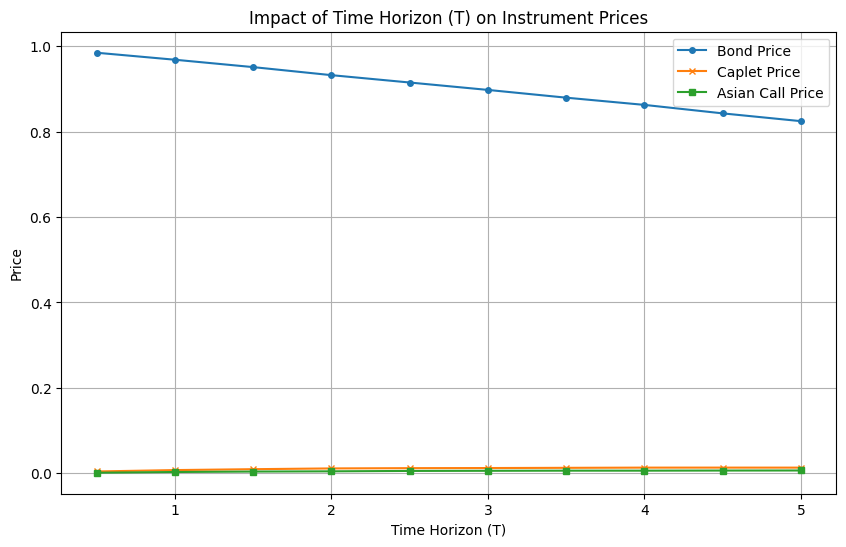

In [22]:
T_values = np.linspace(0.5, 5.0, 10)

bond_prices_T = []
caplet_prices_T = []
asian_call_prices_T = []

# Extract baseline MC parameters (num_simulations, num_steps)
num_simulations = baseline_mc_params['num_simulations']
num_steps = baseline_mc_params['num_steps']

# Keep other Vasicek parameters at baseline
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']

for current_T in T_values:
    # Calculate bond price
    bond_price = monte_carlo_vasicek_pricing(
        x0, current_T, num_simulations, num_steps, bond_payoff, a, b, sigma
    )
    bond_prices_T.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_vasicek_pricing(
        x0, current_T, num_simulations, num_steps, lambda path: caplet_payoff(caplet_strike, path), a, b, sigma
    )
    caplet_prices_T.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_vasicek_pricing(
        x0, current_T, num_simulations, num_steps, lambda path: asian_call_payoff(asian_call_strike, path), a, b, sigma
    )
    asian_call_prices_T.append(asian_call_price)

plt.figure(figsize=(10, 6))
plt.plot(T_values, bond_prices_T, label='Bond Price', marker='o', markersize=4)
plt.plot(T_values, caplet_prices_T, label='Caplet Price', marker='x', markersize=4)
plt.plot(T_values, asian_call_prices_T, label='Asian Call Price', marker='s', markersize=4)

plt.title('Impact of Time Horizon (T) on Instrument Prices')
plt.xlabel('Time Horizon (T)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
#Tabulating results

import pandas as pd

# 1. Impact of 'a'
df_a_impact = pd.DataFrame({
    'a': a_values,
    'Bond Price': bond_prices_a,
    'Caplet Price': caplet_prices_a,
    'Asian Call Price': asian_call_prices_a
})
print("\n--- Impact of 'a' ---")
print(df_a_impact.to_markdown(index=False))

# 2. Impact of 'b'
df_b_impact = pd.DataFrame({
    'b': b_values,
    'Bond Price': bond_prices_b,
    'Caplet Price': caplet_prices_b,
    'Asian Call Price': asian_call_prices_b
})
print("\n--- Impact of 'b' ---")
print(df_b_impact.to_markdown(index=False))

# 3. Impact of 'sigma'
df_sigma_impact = pd.DataFrame({
    'sigma': sigma_values,
    'Bond Price': bond_prices_sigma,
    'Caplet Price': caplet_prices_sigma,
    'Asian Call Price': asian_call_prices_sigma
})
print("\n--- Impact of 'sigma' ---")
print(df_sigma_impact.to_markdown(index=False))

# 4. Impact of 'x0'
df_x0_impact = pd.DataFrame({
    'x0': x0_values,
    'Bond Price': bond_prices_x0,
    'Caplet Price': caplet_prices_x0,
    'Asian Call Price': asian_call_prices_x0
})
print("\n--- Impact of 'x0' ---")
print(df_x0_impact.to_markdown(index=False))

# 5. Impact of 'T'
df_T_impact = pd.DataFrame({
    'T': T_values,
    'Bond Price': bond_prices_T,
    'Caplet Price': caplet_prices_T,
    'Asian Call Price': asian_call_prices_T
})
print("\n--- Impact of 'T' ---")
print(df_T_impact.to_markdown(index=False))



--- Impact of 'a' ---
|        a |   Bond Price |   Caplet Price |   Asian Call Price |
|---------:|-------------:|---------------:|-------------------:|
| 0.1      |     0.969707 |     0.00726461 |         0.00292601 |
| 0.422222 |     0.967106 |     0.00818407 |         0.003181   |
| 0.744444 |     0.964748 |     0.00846533 |         0.00335517 |
| 1.06667  |     0.963179 |     0.00876352 |         0.00355428 |
| 1.38889  |     0.961401 |     0.0091225  |         0.00370679 |
| 1.71111  |     0.960178 |     0.00944418 |         0.00379908 |
| 2.03333  |     0.959328 |     0.00989849 |         0.0041044  |
| 2.35556  |     0.95851  |     0.0098741  |         0.00435283 |
| 2.67778  |     0.957934 |     0.0101334  |         0.00467102 |
| 3        |     0.957095 |     0.0102166  |         0.00483811 |

--- Impact of 'b' ---
|    b |   Bond Price |   Caplet Price |   Asian Call Price |
|-----:|-------------:|---------------:|-------------------:|
| 0.01 |     0.973068 |     0.00426887

In [ ]:
# Comparison of monte-carlo vs analythical bond price

def vasicek_analytical_bond_price(a, b, sigma, x0, T_maturity):
    """
    Calculates the analytical zero-coupon bond price under the Vasicek model.

    Args:
        a (float): Speed of mean reversion.
        b (float): Long-term mean interest rate.
        sigma (float): Volatility.
        x0 (float): Initial interest rate.
        T_maturity (float): Time to maturity (T).

    Returns:
        float: The analytical zero-coupon bond price.
    """

    # Calculate B(T)
    B_T = (1 - np.exp(-a * T_maturity)) / a

    # Calculate A(T)
    A_T = np.exp((B_T - T_maturity) * (a**2 * b - 0.5 * sigma**2) / (a**2) - sigma**2 * B_T**2 / (4 * a))

    # Calculate Bond Price P(0, T)
    bond_price = A_T * np.exp(-B_T * x0)
    return bond_price

# Extract baseline parameters
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']
T_maturity = baseline_vasicek_params['T']

# Calculate analytical bond price
analy_bond_price = vasicek_analytical_bond_price(a, b, sigma, x0, T_maturity)

print(f"Analytical Bond Price: {analy_bond_price:.6f}")
print(f"Monte Carlo Bond Price (Baseline): {baseline_bond_price:.6f}")

In [ ]:
def jump_asian_call_payoff(strike, path, times):
    """
    Calculates the payoff for a European Asian call option for the jump model.
    In the jump model the values of the path are not equally spaced, so we need
    a payoff function that takes into account the times as well.

    Args:
        strike (float): The strike price of the option.
        path (np.ndarray): The simulated interest rate path.
        times (np.ndarray): The jump time points corresponding to the path.

    Returns:
        float: The payoff of the Asian call option.
    """
    average_rate = np.sum(path*(times[1:]-times[:-1]))/times[-1]
    return max(0, average_rate - strike)

In [29]:
def monte_carlo_jump_pricing(x0, T, num_simulations, jump_intensity, payoff_function, a, b, sigma):
    discounted_payoffs = []

    a_func = lambda x, t: a * (b - x)
    b_func = lambda x, t: sigma

    for _ in range(num_simulations):
        # Simulate the interest rate path using the jump model
        times, path = jump_model(x0, jump_intensity, t_start=0, t_end=T, a=a_func, b=b_func)

        times = np.append(times, T)
        integral_rate = np.sum(path*(times[1:]-times[:-1]))

        discount_factor = np.exp(-integral_rate)

        # Apply the payoff function to the entire path
        payoff = payoff_function(path, times)

        # Calculate discounted payoff and add to list
        discounted_payoffs.append(payoff * discount_factor)

    # Return the average of all discounted payoffs
    return np.mean(discounted_payoffs)


# Define a range for jump intensity (lambda)
lambda_values = np.array([2, 10, 50, 250, 1250, 6000])

bond_prices_jump = []
caplet_prices_jump = []
asian_call_prices_jump = []

# Extract baseline parameters
a = baseline_vasicek_params['a']
b = baseline_vasicek_params['b']
sigma = baseline_vasicek_params['sigma']
x0 = baseline_vasicek_params['x0']
T = baseline_vasicek_params['T']
num_simulations = 10000 #baseline_mc_params['num_simulations']
#num_steps = baseline_mc_params['num_steps'] # Not directly used by jump model, but good to keep context

for current_lambda in lambda_values:
    # Calculate bond price
    bond_price = monte_carlo_jump_pricing(
        x0, T, num_simulations, current_lambda, lambda path, times: bond_payoff(path), a, b, sigma
    )
    bond_prices_jump.append(bond_price)

    # Calculate caplet price
    caplet_price = monte_carlo_jump_pricing(
        x0, T, num_simulations, current_lambda, lambda path, times: caplet_payoff(caplet_strike, path), a, b, sigma
    )
    caplet_prices_jump.append(caplet_price)

    # Calculate Asian call option price
    asian_call_price = monte_carlo_jump_pricing(
        x0, T, num_simulations, current_lambda, lambda path, times: jump_asian_call_payoff(asian_call_strike, path, times), a, b, sigma
    )
    asian_call_prices_jump.append(asian_call_price)


# --- Plotting Convergence ---

# Get continuous model prices for comparison
continuous_bond_price_mc = baseline_bond_price # Already calculated
continuous_caplet_price_mc = baseline_caplet_price # Already calculated
continuous_asian_call_price_mc = baseline_asian_call_price # Already calculated

# Bond Price Convergence
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, bond_prices_jump, label='Jump Model Bond Price', marker='o', markersize=5)
plt.axhline(y=continuous_bond_price_mc, color='red', linestyle='--', label='Continuous Model (MC)')
plt.axhline(y=analy_bond_price, color='green', linestyle=':', label='Continuous Model (Analytical)')
plt.title('Convergence of Bond Price (Jump Model to Continuous Model)')
plt.xlabel('Jump Intensity (lambda)')
plt.ylabel('Bond Price')
plt.xscale('log') # Use log scale for better visualization of lambda
plt.legend()
plt.grid(True)
plt.show()

# Caplet Price Convergence
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, caplet_prices_jump, label='Jump Model Caplet Price', marker='o', markersize=5)
plt.axhline(y=continuous_caplet_price_mc, color='red', linestyle='--', label='Continuous Model (MC)')
plt.title('Convergence of Caplet Price (Jump Model to Continuous Model)')
plt.xlabel('Jump Intensity (lambda)')
plt.ylabel('Caplet Price')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()

# Asian Call Option Price Convergence
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, asian_call_prices_jump, label='Jump Model Asian Call Price', marker='o', markersize=5)
plt.axhline(y=continuous_asian_call_price_mc, color='red', linestyle='--', label='Continuous Model (MC)')
plt.title('Convergence of Asian Call Option Price (Jump Model to Continuous Model)')
plt.xlabel('Jump Intensity (lambda)')
plt.ylabel('Asian Call Price')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'baseline_bond_price' is not defined